## **3° Module**: TT - Radiomic Feature Extraction
* September 23°, 2026
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia

#### **0° Introduction**

Module 3 turns each aligned (image, mask) pair from Module 2 into a vector of
**radiomic features**: quantitative descriptors of the lesion's intensity, shape and
texture, each with a defined morphological meaning. This is Strategy A of the report,
chosen over a CNN encoder for its clinical interpretability (D-006).

The configuration is fixed by earlier decisions:

| Setting | Value | Reason |
|---|---|---|
| Feature families | first-order, shape2D, GLCM, GLRLM | the four declared in §4.5 (D-023) |
| Image | original only, no filters | filtered features lose their direct interpretation (D-023) |
| Discretisation | `binCount=32` | intensities are arbitrary and uncalibrated (D-008) |
| Resolution | native, no resampling | size carries the strongest signal (D-009) |
| Spacing | $(1, 1)$, pixel units | `PixelSpacing` is absent from every DICOM (H-002) |
| Intensity normalisation | none | M2 keeps raw 16-bit values (D-022) |

Both exported variants are processed: the **raw** crop, which is the radiomic path, and
the **CLAHE** crop, only to measure the effect CLAHE would have had (D-010).

Beyond extracting, the notebook answers three questions:

1. Are the features sound: no failures, no degenerate columns, and consistent between
   the two variants where they must be?
2. How discriminative is each feature, and which ones will `SelectKBest(k=12)` pick in
   Module 4? (H-003 answered this on only 20 masses.)
3. What does CLAHE change?

#### **1° Setup**

**a.** Import the necessary libraries

In [1]:
import time
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import radiomics
from radiomics import featureextractor

warnings.filterwarnings("ignore")
logging.getLogger("radiomics").setLevel(logging.ERROR)

print("Environment:")
print(f"  pyradiomics : {radiomics.__version__}  (built from commit 8ed5793, see Code/env/README.md)")
print(f"  numpy       : {np.__version__}")
print(f"  pandas      : {pd.__version__}")

Environment:
  pyradiomics : 0.1.dev1+g8ed579383  (built from commit 8ed5793, see Code/env/README.md)
  numpy       : 2.2.6
  pandas      : 2.3.3


**b.** Configuration

In [ ]:
SEED = 42
DATA_DIR = Path("/Users/alexander_san/TT/Data")
OUT_DIR = DATA_DIR / "processed" / "m3" 
RESULTS_DIR = Path("/Users/alexander_san/TT/Code/results")
FIG_DIR = Path("/Users/alexander_san/TT/Docs/Figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FAMILIES = ["firstorder", "shape2D", "glcm", "glrlm"]
VARIANTS = {"raw": "path_image", "clahe": "path_clahe"}
FINDINGS = ["mass", "calcification"]
K_SELECT = 12                                

META = ["case_id", "patient_id", "finding_type", "split", "label", "pathology",
        "mismatch", "crop_check", "mask_area"]

index = pd.read_parquet(DATA_DIR / "processed" / "m2_index.parquet")
print(f"Module 2 index: {len(index)} lesions")
print(index.groupby(["finding_type", "split"]).size().unstack())

Module 2 index: 3568 lesions
split          test  train
finding_type              
calcification   326   1546
mass            378   1318


#### **2° Extractor configuration**

Only the four families are enabled, on the original image. Two settings deserve a
comment:

- `force2D=True`: the images are 2D, and this makes PyRadiomics compute the texture
  matrices in-plane, with the four 2D directions (0°, 45°, 90°, 135°) at distance 1 and
  the features averaged over directions.
- `normalize=False` (the default): with `binCount`, the grey levels are defined from the
  minimum and maximum *inside the mask*, so the texture features are already invariant
  to a linear change of intensity. First-order features are not, and they are computed
  on the raw values on purpose.

In [3]:
extractor = featureextractor.RadiomicsFeatureExtractor(binCount=32, force2D=True, label=1)
extractor.disableAllFeatures()
for fam in FAMILIES:
    extractor.enableFeatureClassByName(fam)

print("Settings:")
for k in ("binCount", "force2D", "distances", "normalize", "resampledPixelSpacing", "label"):
    print(f"  {k:22s}: {extractor.settings.get(k)}")
print(f"Image types: {list(extractor.enabledImagetypes)}")

probe = index.iloc[0]
probe_feats = extractor.execute(str(DATA_DIR / probe.path_image), str(DATA_DIR / probe.path_mask))
FEATURES = [k for k in probe_feats if k.startswith("original_")]
family_of = lambda name: name.split("_")[1]
print(f"\nEnabled features: {len(FEATURES)}")
print(pd.Series([family_of(f) for f in FEATURES]).value_counts().to_string())

Settings:
  binCount              : 32
  force2D               : True
  distances             : [1]
  normalize             : False
  resampledPixelSpacing : None
  label                 : 1
Image types: ['Original']

Enabled features: 67
glcm          24
firstorder    18
glrlm         16
shape2D        9


#### **3° Extraction**

Every lesion is processed with both variants. A failure on one case is recorded and does
not stop the run. The cost grows linearly with the area of the lesion, about 0.25 s per
megapixel, so the whole run takes minutes and needs no parallelism.

In [4]:
def extract(row, variant):
    try:
        f = extractor.execute(str(DATA_DIR / row[VARIANTS[variant]]), str(DATA_DIR / row.path_mask))
        return {k: float(f[k]) for k in FEATURES}, None
    except Exception as exc:  # recorded, not raised
        return {k: np.nan for k in FEATURES}, f"{type(exc).__name__}: {exc}"


tables, failures, timing = {}, [], {}
for variant in VARIANTS:
    t0 = time.time()
    rows = []
    for _, row in index.iterrows():
        feats, err = extract(row, variant)
        if err:
            failures.append(dict(case_id=row.case_id, variant=variant, error=err))
        rows.append({**{m: row[m] for m in META}, **feats})
    tables[variant] = pd.DataFrame(rows)
    timing[variant] = time.time() - t0
    print(f"{variant:5s}: {len(rows)} lesions in {timing[variant] / 60:.1f} min")

print(f"\nFailures: {len(failures)}")
if failures:
    print(pd.DataFrame(failures).to_string(index=False))

raw  : 3568 lesions in 3.1 min


clahe: 3568 lesions in 3.0 min

Failures: 0


**Save**

One file per finding type and variant, so that masses and calcifications are never mixed
downstream (D-005). Module 4 reads the `raw` files.

In [5]:
for variant, tab in tables.items():
    for ft in FINDINGS:
        path = OUT_DIR / f"features_{ft}_{variant}.parquet"
        tab[tab.finding_type == ft].reset_index(drop=True).to_parquet(path, index=False)
        print(f"  {path.relative_to(DATA_DIR)}  {(tab.finding_type == ft).sum()} rows × {len(FEATURES)} features")

  processed/m3/features_mass_raw.parquet  1696 rows × 67 features
  processed/m3/features_calcification_raw.parquet  1872 rows × 67 features
  processed/m3/features_mass_clahe.parquet  1696 rows × 67 features
  processed/m3/features_calcification_clahe.parquet  1872 rows × 67 features


#### **4° Quality checks**

**a.** Missing values and degenerate columns

A feature that is constant within a subset carries no information there and would break
the F-test of Module 4 (zero variance within classes).

In [6]:
qc_rows = []
for variant, tab in tables.items():
    for ft in FINDINGS:
        sub = tab[tab.finding_type == ft][FEATURES]
        for f in FEATURES:
            v = sub[f]
            qc_rows.append(dict(variant=variant, finding_type=ft, feature=f, family=family_of(f),
                                n_nan=int(v.isna().sum()), n_inf=int(np.isinf(v).sum()),
                                n_unique=int(v.nunique()), std=float(v.std())))
qc = pd.DataFrame(qc_rows)
qc.to_csv(RESULTS_DIR / "3_calidad_features.csv", index=False)

print(qc.groupby(["variant", "finding_type"]).agg(
    nan=("n_nan", "sum"), inf=("n_inf", "sum"),
    constant=("n_unique", lambda u: (u <= 1).sum()),
    few_values=("n_unique", lambda u: (u < 10).sum())).to_string())
low = qc[qc.n_unique < 10]
if len(low):
    print("\nFeatures with fewer than 10 distinct values:")
    print(low[["variant", "finding_type", "feature", "n_unique"]].to_string(index=False))

                       nan  inf  constant  few_values
variant finding_type                                 
clahe   calcification    0    0         0           0
        mass             0    0         0           0
raw     calcification    0    0         0           0
        mass             0    0         0           0


**b.** Consistency checks

Two properties must hold exactly if the pipeline is right, and each is a test that
nothing was mismatched on the way:

- The **shape** features depend only on the mask, and both variants share it, so they
  must be identical between `raw` and `clahe`.
- `PixelSurface` counts the pixels of the mask, so it must equal the mask area that
  Module 2 recorded, computed by different software.

In [7]:
raw, eq = tables["raw"].set_index("case_id"), tables["clahe"].set_index("case_id")
shape_cols = [f for f in FEATURES if family_of(f) == "shape2D"]
shape_diff = (raw[shape_cols] - eq.loc[raw.index, shape_cols]).abs().max().max()
pix_ok = (raw["original_shape2D_PixelSurface"] == raw["mask_area"]).mean()
print(f"Max |raw - clahe| over the {len(shape_cols)} shape features: {shape_diff:.3g}")
print(f"PixelSurface == Module 2 mask area: {pix_ok:.1%} of lesions")

Max |raw - clahe| over the 9 shape features: 0
PixelSurface == Module 2 mask area: 100.0% of lesions


#### **5° Discriminative power**

**a.** Effect size on the training set

For each feature and subset, **Cohen's $d$** between malignant and benign lesions, with
the pooled standard deviation:

$$d = \frac{\bar{x}_1 - \bar{x}_0}{s_p}, \qquad
s_p = \sqrt{\frac{(n_1 - 1)s_1^2 + (n_0 - 1)s_0^2}{n_1 + n_0 - 2}}.$$

Only the **training** split is used, which is where Module 4 fits its selector.

There is a direct link with Module 4. For two classes, the ANOVA F statistic that
`SelectKBest(f_classif)` uses is the square of the two-sample $t$ statistic, and
$t = d\sqrt{n_0 n_1 / (n_0 + n_1)}$. Within a subset every feature shares the same $n_0$ and
$n_1$, so **ranking by $F$ is ranking by $|d|$**: the top 12 by $|d|$ below are the 12
features Module 4 will select. The check after the table computes $F$ independently and
confirms the equivalence. The selection itself belongs to Module 4; here it is only
previewed.

In [8]:
def cohen_d(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    n1, n0 = len(x), len(y)
    sp = np.sqrt(((n1 - 1) * x.var(ddof=1) + (n0 - 1) * y.var(ddof=1)) / (n1 + n0 - 2))
    return (x.mean() - y.mean()) / sp if sp > 0 else np.nan


def anova_f(x, y):
    # one-way ANOVA F for two groups, computed from sums of squares
    allv = np.concatenate([x, y])
    ssb = len(x) * (x.mean() - allv.mean())**2 + len(y) * (y.mean() - allv.mean())**2
    ssw = ((x - x.mean())**2).sum() + ((y - y.mean())**2).sum()
    return (ssb / 1) / (ssw / (len(allv) - 2))


eff_rows = []
for variant, tab in tables.items():
    for ft in FINDINGS:
        tr = tab[(tab.finding_type == ft) & (tab.split == "train")]
        mal, ben = tr[tr.label == 1], tr[tr.label == 0]
        for f in FEATURES:
            eff_rows.append(dict(variant=variant, finding_type=ft, feature=f, family=family_of(f),
                                 d=cohen_d(mal[f], ben[f]), F=anova_f(mal[f].values, ben[f].values),
                                 n_malignant=len(mal), n_benign=len(ben)))
eff = pd.DataFrame(eff_rows)
eff["abs_d"] = eff.d.abs()
eff["rank"] = eff.groupby(["variant", "finding_type"]).abs_d.rank(ascending=False, method="first").astype(int)

short = lambda f: f.replace("original_", "")
for ft in FINDINGS:
    e = eff[(eff.variant == "raw") & (eff.finding_type == ft)].sort_values("rank")
    print(f"== {ft} (train: {e.n_malignant.iloc[0]} malignant, {e.n_benign.iloc[0]} benign)")
    print(e.head(15).assign(feature=e.feature.map(short))[["rank", "feature", "d", "F"]]
          .to_string(index=False, float_format=lambda v: f"{v:.3f}"))
    print()

agree = []
for (v, ft), g in eff.groupby(["variant", "finding_type"]):
    top_d = set(g.nlargest(K_SELECT, "abs_d").feature)
    top_f = set(g.nlargest(K_SELECT, "F").feature)
    agree.append(top_d == top_f)
print(f"Top {K_SELECT} by |d| == top {K_SELECT} by F in all {len(agree)} (variant, subset) pairs: {all(agree)}")

== mass (train: 637 malignant, 681 benign)
 rank                       feature      d      F
    1            firstorder_Maximum  0.502 83.093
    2       firstorder_90Percentile  0.501 82.592
    3             firstorder_Energy  0.476 74.704
    4        firstorder_TotalEnergy  0.476 74.704
    5       shape2D_MinorAxisLength  0.450 66.731
    6             firstorder_Median  0.444 64.909
    7    firstorder_RootMeanSquared  0.442 64.235
    8       shape2D_MaximumDiameter  0.435 62.284
    9               firstorder_Mean  0.434 62.067
   10       shape2D_MajorAxisLength  0.428 60.167
   11             shape2D_Perimeter  0.402 53.114
   12           shape2D_MeshSurface  0.400 52.778
   13          shape2D_PixelSurface  0.400 52.778
   14 shape2D_PerimeterSurfaceRatio -0.395 51.320
   15  glrlm_GrayLevelNonUniformity  0.339 37.816

== calcification (train: 544 malignant, 1002 benign)
 rank                                feature      d       F
    1                shape2D_MinorAxisLengt

**b.** Which families reach the top 12, and how redundant they are

This is the check requested by D-013: if the twelve selected features were near-copies
of one another, the pairwise products $x_i x_j$ encoded by the feature map would carry
little new information.

In [9]:
summary_rows = []
for ft in FINDINGS:
    tr = tables["raw"][(tables["raw"].finding_type == ft) & (tables["raw"].split == "train")]
    top = eff[(eff.variant == "raw") & (eff.finding_type == ft)].nsmallest(K_SELECT, "rank")
    C = tr[top.feature].corr().abs().values
    off = C[~np.eye(len(C), dtype=bool)]
    fam_counts = top.family.value_counts().reindex(FAMILIES, fill_value=0)
    summary_rows.append(dict(finding_type=ft, **{f"n_{k}": v for k, v in fam_counts.items()},
                             max_abs_d=top.abs_d.max(), min_abs_d_in_top=top.abs_d.min(),
                             mean_abs_corr=off.mean(), pairs_corr_above_0_95=int((off > 0.95).sum() / 2)))
    print(f"== {ft}: families in the top {K_SELECT}: {fam_counts.to_dict()}")
    print(f"   mean |r| between the {K_SELECT}: {off.mean():.3f}   pairs with |r| > 0.95: {int((off > 0.95).sum() / 2)} of {K_SELECT * (K_SELECT - 1) // 2}")
top_summary = pd.DataFrame(summary_rows)
eff.to_csv(RESULTS_DIR / "3_tamano_efecto.csv", index=False)

== mass: families in the top 12: {'firstorder': 7, 'shape2D': 5, 'glcm': 0, 'glrlm': 0}
   mean |r| between the 12: 0.613   pairs with |r| > 0.95: 8 of 66
== calcification: families in the top 12: {'firstorder': 1, 'shape2D': 2, 'glcm': 4, 'glrlm': 5}
   mean |r| between the 12: 0.576   pairs with |r| > 0.95: 5 of 66


**c.** Visualization

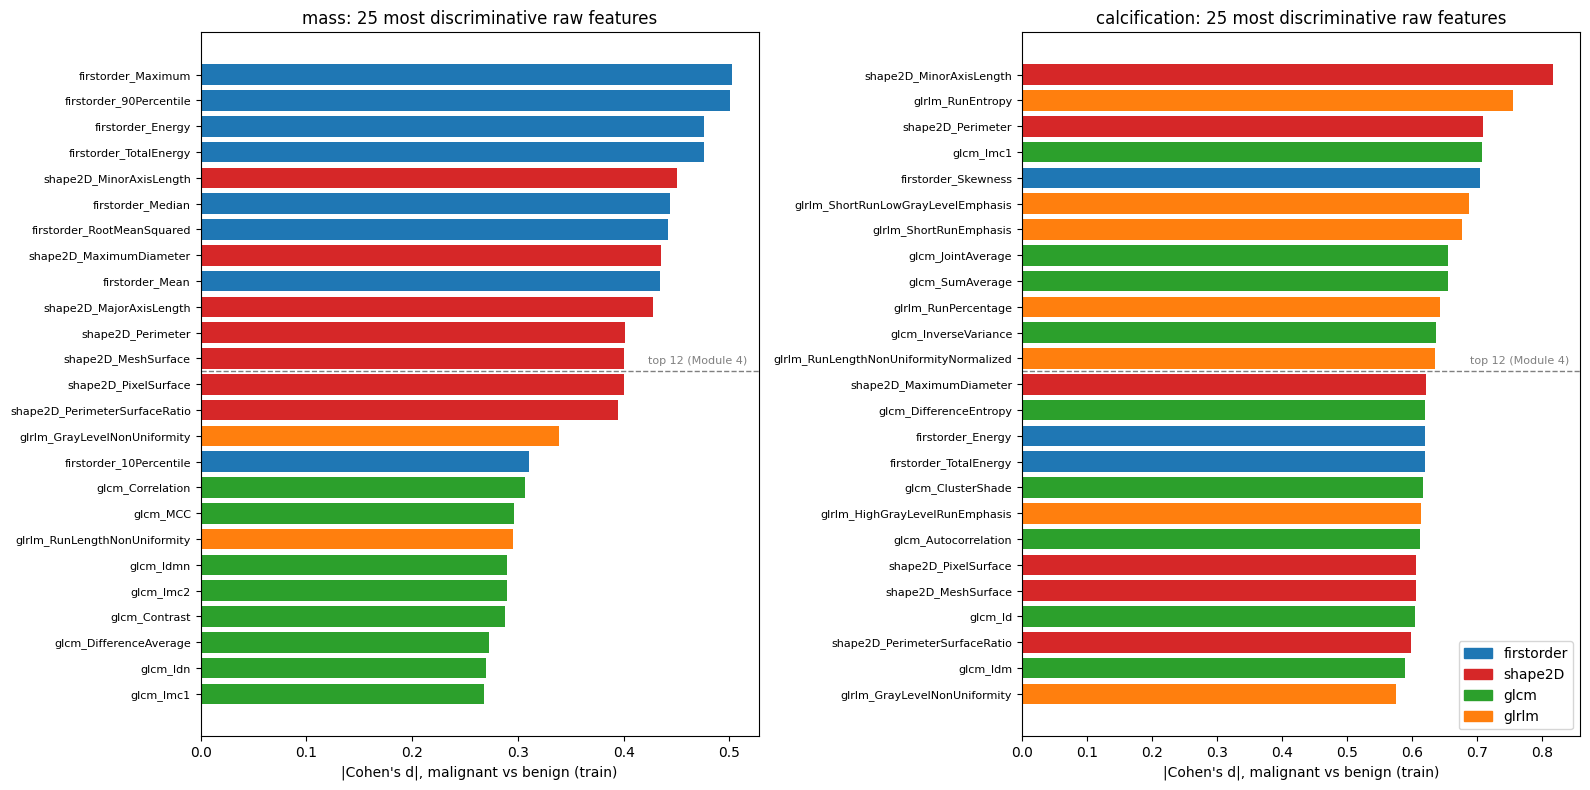

In [10]:
colors = {"firstorder": "C0", "shape2D": "C3", "glcm": "C2", "glrlm": "C1"}
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, ft in zip(axes, FINDINGS):
    e = eff[(eff.variant == "raw") & (eff.finding_type == ft)].nsmallest(25, "rank").iloc[::-1]
    ax.barh(e.feature.map(short), e.abs_d, color=e.family.map(colors))
    ax.axhline(len(e) - K_SELECT - 0.5, color="gray", ls="--", lw=1)
    ax.text(ax.get_xlim()[1] * 0.98, len(e) - K_SELECT - 0.2, f"top {K_SELECT} (Module 4)", ha="right", fontsize=8, color="gray")
    ax.set_xlabel("|Cohen's d|, malignant vs benign (train)")
    ax.set_title(f"{ft}: 25 most discriminative raw features")
    ax.tick_params(axis="y", labelsize=8)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
axes[1].legend(handles, colors.keys(), loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "M3_effect_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

**d.** Consequence

Three results change what was expected.

**1. The effect sizes are moderate, not large.** On the 1,318 training masses the
strongest feature reaches $|d| = 0.50$, and five shape features sit between $0.40$ and
$0.45$. H-003 had reported $|d| \approx 1.42$ for the top five shape features, but on only
20 masses: it was a small-sample artefact, the same failure mode as H-012 and H-017.
Calcifications turn out to be the *more* separable subset here ($|d|$ up to $0.82$), the
opposite of what the EDA suggested.

**2. For masses the top 12 contains no texture at all.** Seven first-order intensity
features and five shape features. The content argument of D-013, that $k = 12$ lets
texture in next to shape, does not hold for masses. For calcifications the top 12 is
diverse: five GLRLM, four GLCM, two shape and one first-order.

**3. The ranking contains exact duplicates.** Three pairs are identical by definition in
2D with unit spacing: `Energy` and `TotalEnergy` (the pixel area is 1), `JointAverage`
and `SumAverage` ($= 2\times$ for a symmetric GLCM) and, to $r = 1.0000$, `MeshSurface`
and `PixelSurface`. Beyond those, 20 pairs among masses and 11 among calcifications have
$|r| > 0.99$. Selected as they are, `Energy` and `TotalEnergy` would occupy two qubits
with the same value, and `Mean`, `Median` and `RootMeanSquared` three with nearly the
same one. How to deduplicate before `SelectKBest` is a decision for Module 4.

A caution on the first-order features that lead the mass ranking: they are computed on
**uncalibrated** raw intensities (D-008, H-002), and the DDSM mixes digitisers. That
malignant masses are brighter is clinically plausible, since high density is a sign of
malignancy, but part of the signal could come from acquisition. The data available
cannot separate the two, because `Manufacturer` is missing everywhere.

#### **6° What CLAHE changes (D-010)**

Two scale-free comparisons per feature, on the training set, between the raw and the CLAHE
variant. Shape features are excluded: they are identical by construction.

- **Spearman correlation across lesions**: does CLAHE preserve the *ordering* of lesions?
  A value near 1 means the feature ranks lesions the same way with or without CLAHE.
- **Change in $|d|$**: does CLAHE make the feature more or less discriminative?

First-order values themselves are not comparable, because the raw crop is 16-bit and the
CLAHE crop 8-bit; both comparisons above are invariant to that.

In [11]:
def spearman(a, b):
    ra, rb = pd.Series(a).rank().values, pd.Series(b).rank().values
    return np.corrcoef(ra, rb)[0, 1]


cl_rows = []
for ft in FINDINGS:
    r = tables["raw"][(tables["raw"].finding_type == ft) & (tables["raw"].split == "train")].set_index("case_id")
    c = tables["clahe"].set_index("case_id").loc[r.index]
    for f in FEATURES:
        if family_of(f) == "shape2D":
            continue
        d_raw = eff.query("variant == 'raw' and finding_type == @ft and feature == @f").abs_d.iloc[0]
        d_eq = eff.query("variant == 'clahe' and finding_type == @ft and feature == @f").abs_d.iloc[0]
        cl_rows.append(dict(finding_type=ft, feature=f, family=family_of(f),
                            spearman_raw_clahe=spearman(r[f], c[f]), abs_d_raw=d_raw, abs_d_clahe=d_eq,
                            delta_abs_d=d_eq - d_raw))
cl = pd.DataFrame(cl_rows)
cl.to_csv(RESULTS_DIR / "3_efecto_clahe.csv", index=False)
print(cl.groupby(["finding_type", "family"]).agg(
    features=("feature", "size"),
    spearman_median=("spearman_raw_clahe", "median"), spearman_min=("spearman_raw_clahe", "min"),
    delta_abs_d_median=("delta_abs_d", "median"),
    more_discriminative=("delta_abs_d", lambda s: (s > 0).sum())).round(3).to_string())

                          features  spearman_median  spearman_min  delta_abs_d_median  more_discriminative
finding_type  family                                                                                      
calcification firstorder        18            0.834         0.678              -0.054                    6
              glcm              24            0.860         0.439               0.014                   14
              glrlm             16            0.881         0.739              -0.035                    6
mass          firstorder        18            0.836         0.627              -0.031                    1
              glcm              24            0.856         0.563               0.002                   15
              glrlm             16            0.879         0.666               0.011                   13


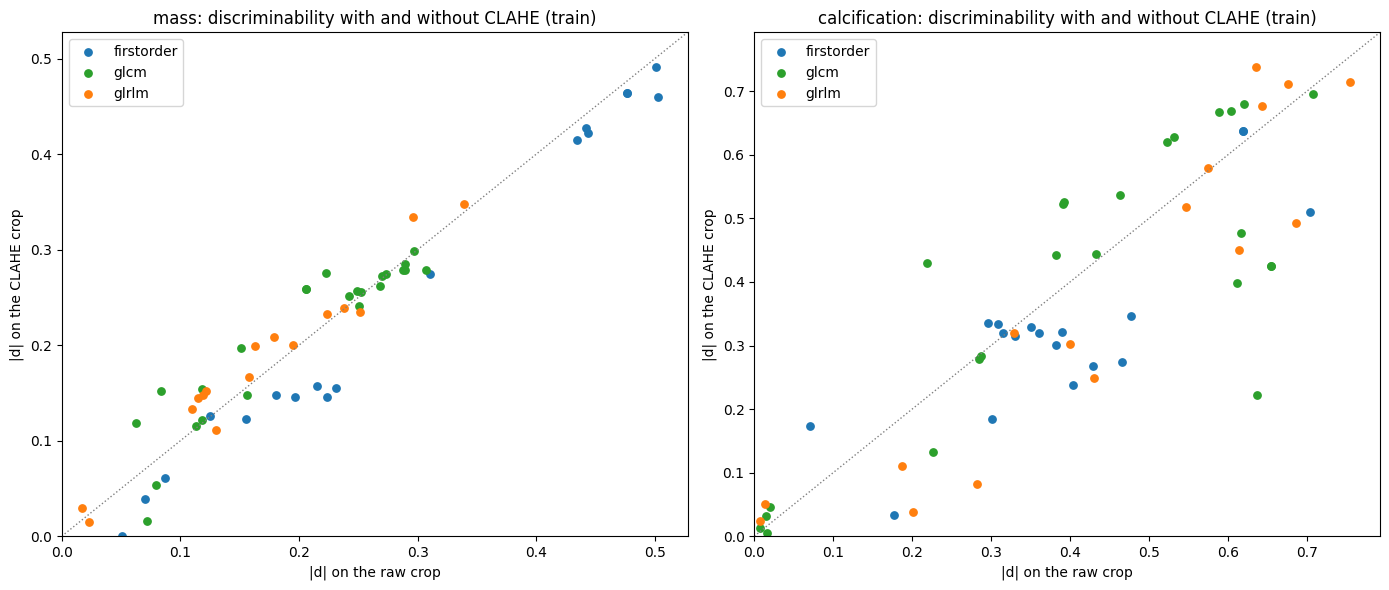

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, ft in zip(axes, FINDINGS):
    g = cl[cl.finding_type == ft]
    for fam, h in g.groupby("family"):
        ax.scatter(h.abs_d_raw, h.abs_d_clahe, color=colors[fam], label=fam, s=28)
    lim = max(g.abs_d_raw.max(), g.abs_d_clahe.max()) * 1.05
    ax.plot([0, lim], [0, lim], color="gray", ls=":", lw=1)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("|d| on the raw crop"); ax.set_ylabel("|d| on the CLAHE crop")
    ax.set_title(f"{ft}: discriminability with and without CLAHE (train)")
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "M3_clahe_effect.png", dpi=150, bbox_inches="tight")
plt.show()

**Consequence**

CLAHE **changes the features but not their discriminability**. It reorders the lesions
considerably, with a median Spearman correlation against the raw features of about
$0.84$, yet the median change in $|d|$ is essentially zero in both subsets ($-0.002$ in
masses, $-0.010$ in calcifications). It shifts discriminability between families
rather than adding any. First-order features lose, which is expected from an equalisation
that rewrites the intensities. Some texture features gain, most visibly GLCM in
calcifications. The most discriminative features of each subset do not improve.

This closes D-010 with evidence. Keeping CLAHE out of the radiomic path costs no
discriminative signal and keeps the features reproducible under IBSI.

#### **7° Summary**

In [13]:
print("=" * 72)
print("MODULE 3 - RADIOMIC FEATURE EXTRACTION - SUMMARY")
print("=" * 72)
print(f"  Lesions      : {len(index)} × 2 variants, {len(FEATURES)} features each "
      f"({', '.join(f'{k} {v}' for k, v in pd.Series([family_of(f) for f in FEATURES]).value_counts().items())})")
print(f"  Time         : raw {timing['raw'] / 60:.1f} min, clahe {timing['clahe'] / 60:.1f} min")
print(f"  Failures     : {len(failures)}")
print(f"  NaN / inf    : {int(qc.n_nan.sum())} / {int(qc.n_inf.sum())};  constant columns: {int((qc.n_unique <= 1).sum())}")
print(f"  Consistency  : shape raw vs clahe max diff {shape_diff:.3g};  PixelSurface == mask area in {pix_ok:.1%}")
print()
for _, r in top_summary.iterrows():
    e = eff[(eff.variant == "raw") & (eff.finding_type == r.finding_type)].nsmallest(1, "rank").iloc[0]
    print(f"  {r.finding_type:13s}: top feature {short(e.feature)} (|d| = {e.abs_d:.2f});")
    print(f"                 top {K_SELECT}: {r.n_firstorder} first-order, {r.n_shape2D} shape, {r.n_glcm} GLCM, {r.n_glrlm} GLRLM;"
          f" |d| from {r.min_abs_d_in_top:.2f} to {r.max_abs_d:.2f}; mean |r| {r.mean_abs_corr:.2f}")
print()
g = cl.groupby("finding_type").agg(sp=("spearman_raw_clahe", "median"), dd=("delta_abs_d", "median"))
for ft, r in g.iterrows():
    print(f"  CLAHE, {ft:13s}: median Spearman raw-vs-CLAHE {r.sp:.3f}, median change in |d| {r.dd:+.3f}")
print("=" * 72)

MODULE 3 - RADIOMIC FEATURE EXTRACTION - SUMMARY
  Lesions      : 3568 × 2 variants, 67 features each (glcm 24, firstorder 18, glrlm 16, shape2D 9)
  Time         : raw 3.1 min, clahe 3.0 min
  Failures     : 0
  NaN / inf    : 0 / 0;  constant columns: 0
  Consistency  : shape raw vs clahe max diff 0;  PixelSurface == mask area in 100.0%

  mass         : top feature firstorder_Maximum (|d| = 0.50);
                 top 12: 7 first-order, 5 shape, 0 GLCM, 0 GLRLM; |d| from 0.40 to 0.50; mean |r| 0.61
  calcification: top feature shape2D_MinorAxisLength (|d| = 0.82);
                 top 12: 1 first-order, 2 shape, 4 GLCM, 5 GLRLM; |d| from 0.64 to 0.82; mean |r| 0.58

  CLAHE, calcification: median Spearman raw-vs-CLAHE 0.843, median change in |d| -0.010
  CLAHE, mass         : median Spearman raw-vs-CLAHE 0.837, median change in |d| -0.002
